# Analyse der kaskadierten Rejectoren R1 und R2

Dieses Notebook bildet das praktische Routing auf den **uncut validation data** nach:

`validation -> R1 -> (accept | reject -> R2 -> accept | reject)`

Ein Reject-Score ist die Softmax-Wahrscheinlichkeit der Klasse 1. Ein Sample wird bei `score >= threshold` rejected bzw. an die nächste Stufe weitergereicht. R2 wird ausschließlich für Samples ausgeführt, die R1 rejected hat.

In [16]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import training_models
import training
from embedding_processing_models import build_embedding_processing
from DMTimeShardDataset import DMTimeShardDataset

plt.style.use("ggplot")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Konfiguration

R1 verwendet den statischen Threshold aus der bestehenden R1→R2-Pipeline. `RECOMPUTE_SCORES=False` lädt einen vorhandenen Cache und vermeidet erneute Inferenz.

In [17]:
ROOT = Path("/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training")
DATA_DIR = ROOT.parent / "DM_time_dataset_creator" / "outputs"
OUTPUT_DIR = ROOT / "rejector_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_CFG = {
    "output_dir": str(DATA_DIR),
    "prefix": "B0531+21_59000_48386",
}
BATCH_SIZE = 1024
NUM_WORKERS = 2
RECOMPUTE_SCORES = False
SCORES_CACHE = OUTPUT_DIR / "r1_r2_uncut_val_scores.npz"
ROUTING_CSV = OUTPUT_DIR / "r1_r2_uncut_val_routing.csv.gz"

R1_THRESHOLD = 0.548808
R2_THRESHOLD = 0.381863 

SMALL_CKPT = ROOT / "final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_241002_3_GAP-014-0.764-0.740.pth"
MID_CKPT = ROOT / "final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_241002_5_GAP-060-0.973-0.948.pth"
LARGE_CKPT = ROOT / "final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_resnet18-003-0.993-0.993.pth"
R1_CKPT = ROOT / "final_checkpoints/baseline_rejection_ensemble/prot-run_embedding_3_GAP_conv_mlp_lr1.05e-05_wd0.00e+00_drop0.0_channels64_extraFalse_pool7_hidden64_worker2_trial3-042-0.712-0.635.pth"
R2_CKPT = ROOT / "final_checkpoints/baseline_rejection_ensemble/prot-run_embedding_r2_conv_mlp_lr4.51e-05_wd0.00e+00_drop0.2_channels64_extraTrue_pool7_hidden128_worker13_trial6-035-0.825-0.842.pth"

R1_KWARGS = dict(model_name="conv_mlp", cnn_channels=64, extra_conv=False, pool_size=7, hidden_dim=64, dropout=0.0)
R2_KWARGS = dict(model_name="conv_mlp", cnn_channels=64, extra_conv=True, pool_size=7, hidden_dim=128, dropout=0.2)

LABEL_MAP = {-1.0: "rest of events", 0.0: "zero DM events", 1.0: "pulses"}
META_COLUMNS = ["snr", "t_min", "t_max", "dm", "label_raw"]

for path in (SMALL_CKPT, MID_CKPT, LARGE_CKPT, R1_CKPT, R2_CKPT):
    if not path.exists():
        raise FileNotFoundError(path)
print(f"Outputs: {OUTPUT_DIR}")

Outputs: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis


## Modelle und ungeschnittene Validierungsdaten laden

In [18]:
def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ("model_state_dict", "state_dict", "model"):
            value = checkpoint.get(key)
            if isinstance(value, dict):
                return value
    return checkpoint


def get_rejector_state_dict(checkpoint):
    state_dict = extract_state_dict(checkpoint)
    if not isinstance(state_dict, dict):
        return state_dict
    clean = {}
    for key, value in state_dict.items():
        if key.startswith("1.net."):
            clean[key.replace("1.net.", "net.", 1)] = value
        elif key.startswith("1."):
            clean[key.replace("1.", "", 1)] = value
        elif key.startswith("embedding_processing."):
            clean[key.replace("embedding_processing.", "", 1)] = value
    return clean or state_dict


def load_classifier(model_key, mode, checkpoint_path):
    model = training_models.models_htable[model_key](
        256, mode=mode, dropout=False, device=device
    ).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


def load_rejector(checkpoint_path, kwargs):
    model, feature_source = build_embedding_processing(in_channels=12, **kwargs)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(get_rejector_state_dict(checkpoint))
    model = model.to(device).eval()
    return model, feature_source


small_model = load_classifier(
    "DM_time_binary_classificator_241002_3_GAP", "dmt", SMALL_CKPT
)
mid_model = load_classifier(
    "DM_time_binary_classificator_241002_5_GAP", "ft", MID_CKPT
)
large_model = load_classifier(
    "DM_time_binary_classificator_resnet18", "dmft", LARGE_CKPT
)
r1_model, r1_feature_source = load_rejector(R1_CKPT, R1_KWARGS)
r2_model, r2_feature_source = load_rejector(R2_CKPT, R2_KWARGS)

val_dataset = DMTimeShardDataset(DATASET_CFG, use_freq_time=True, split="val")
val_dataset.labels = training.label_encoding(val_dataset.labels.astype(object))
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)
print(f"Validation samples: {len(val_dataset):,}")

Converting string labels to numeric: ['Artefact' 'Pulse'] -> [0, 1]
Validation samples: 172,032


## Scores einmal berechnen und speichern

Nicht an R2 geroutete Samples erhalten für `r2_score` den Wert `NaN`. So bleibt die praktische Datenverteilung erhalten und die Arrays bleiben trotzdem am vollständigen Validation-Index ausgerichtet.

In [19]:
def classifier_and_rejector_logits(base_model, rejector_model, feature_source, batch):
    model_input = base_model.features(batch)
    if model_input.ndim == 3:
        model_input = model_input.unsqueeze(0)
    classifier_logits = base_model.classifier(model_input)
    features = getattr(base_model, feature_source)(model_input)
    if features.ndim == 3:
        features = features.unsqueeze(0)
    elif feature_source == "pooled_features" and features.ndim == 1:
        features = features.unsqueeze(0)
    return classifier_logits, rejector_model(features)


def classifier_logits(base_model, batch):
    model_input = base_model.features(batch)
    if model_input.ndim == 3:
        model_input = model_input.unsqueeze(0)
    return base_model.classifier(model_input)


def subset_batch(batch, mask):
    # DataLoader liefert hier ausschließlich batch-ausgerichtete Tensoren.
    return {key: value[mask] for key, value in batch.items()}


def compute_cascaded_scores(loader):
    r1_parts, r2_parts, metadata_parts, label_parts = [], [], [], []
    small_pred_parts, mid_pred_parts, large_pred_parts = [], [], []
    with torch.inference_mode():
        for batch in tqdm(loader, desc="Cascaded rejector inference"):
            small_logits, r1_logits = classifier_and_rejector_logits(
                small_model, r1_model, r1_feature_source, batch
            )
            r1_scores = torch.softmax(r1_logits, dim=1)[:, 1]
            r1_rejected = r1_scores >= R1_THRESHOLD
            small_preds = small_logits.argmax(dim=1)

            # R2-Array bleibt am Originalbatch ausgerichtet; nur R1-Rejects werden berechnet.
            r2_scores = torch.full_like(r1_scores, torch.nan)
            mid_preds = torch.full_like(small_preds, -1)
            large_preds = torch.full_like(small_preds, -1)
            if r1_rejected.any():
                r2_batch = subset_batch(batch, r1_rejected.cpu())
                mid_logits, r2_logits = classifier_and_rejector_logits(
                    mid_model, r2_model, r2_feature_source, r2_batch
                )
                r2_scores_subset = torch.softmax(r2_logits, dim=1)[:, 1]
                r2_scores[r1_rejected] = r2_scores_subset
                mid_preds[r1_rejected] = mid_logits.argmax(dim=1)

                # f_large wird nur auf den tatsächlich von R2 rejecteten Samples ausgeführt.
                r2_rejected = r2_scores_subset >= R2_THRESHOLD
                if r2_rejected.any():
                    large_batch = subset_batch(r2_batch, r2_rejected.cpu())
                    large_logits = classifier_logits(large_model, large_batch)
                    r1_positions = torch.where(r1_rejected)[0]
                    large_positions = r1_positions[r2_rejected]
                    large_preds[large_positions] = large_logits.argmax(dim=1)

            r1_parts.append(r1_scores.cpu())
            r2_parts.append(r2_scores.cpu())
            metadata_parts.append(batch["metadata"].cpu())
            label_parts.append(batch["label"].cpu())
            small_pred_parts.append(small_preds.cpu())
            mid_pred_parts.append(mid_preds.cpu())
            large_pred_parts.append(large_preds.cpu())

    return (
        torch.cat(r1_parts).numpy(),
        torch.cat(r2_parts).numpy(),
        torch.cat(metadata_parts).numpy(),
        torch.cat(label_parts).numpy(),
        torch.cat(small_pred_parts).numpy(),
        torch.cat(mid_pred_parts).numpy(),
        torch.cat(large_pred_parts).numpy(),
    )


cache_ok = False
if SCORES_CACHE.exists() and not RECOMPUTE_SCORES:
    cached = np.load(SCORES_CACHE)
    required_cache_keys = {"labels_binary", "small_preds", "mid_preds", "large_preds"}
    cache_ok = (
        required_cache_keys.issubset(cached.files)
        and np.isclose(cached["r1_threshold"].item(), R1_THRESHOLD)
        and np.isclose(cached["r2_threshold"].item(), R2_THRESHOLD)
        and cached["r1_checkpoint"].item() == str(R1_CKPT)
        and cached["r2_checkpoint"].item() == str(R2_CKPT)
        and cached["small_checkpoint"].item() == str(SMALL_CKPT)
        and cached["mid_checkpoint"].item() == str(MID_CKPT)
        and cached["large_checkpoint"].item() == str(LARGE_CKPT)
        and len(cached["r1_scores"]) == len(val_dataset)
    )
    if not cache_ok:
        print("Existing cache does not match checkpoints, R1 threshold, or dataset; recomputing.")

if cache_ok:
    r1_scores = cached["r1_scores"]
    r2_scores = cached["r2_scores"]
    metadata = cached["metadata"]
    labels_binary = cached["labels_binary"]
    small_preds = cached["small_preds"]
    mid_preds = cached["mid_preds"]
    large_preds = cached["large_preds"]
    print(f"Loaded cache: {SCORES_CACHE}")
else:
    (r1_scores, r2_scores, metadata, labels_binary,
     small_preds, mid_preds, large_preds) = compute_cascaded_scores(val_loader)
    np.savez_compressed(
        SCORES_CACHE, r1_scores=r1_scores, r2_scores=r2_scores,
        metadata=metadata, labels_binary=labels_binary, small_preds=small_preds,
        mid_preds=mid_preds, large_preds=large_preds,
        r1_threshold=R1_THRESHOLD, r2_threshold=R2_THRESHOLD,
        r1_checkpoint=str(R1_CKPT), r2_checkpoint=str(R2_CKPT),
        small_checkpoint=str(SMALL_CKPT), mid_checkpoint=str(MID_CKPT),
        large_checkpoint=str(LARGE_CKPT),
    )
    print(f"Saved cache: {SCORES_CACHE}")

assert len(r1_scores) == len(r2_scores) == len(metadata) == len(labels_binary) == len(val_dataset)
print(f"R1 scores: {len(r1_scores):,}; R2 evaluated: {np.isfinite(r2_scores).sum():,}")

Loaded cache: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis/r1_r2_uncut_val_scores.npz
R1 scores: 172,032; R2 evaluated: 51,610


## Routing-Tabelle erzeugen

In [20]:
results = pd.DataFrame(metadata, columns=META_COLUMNS)
results.insert(0, "sample_index", np.arange(len(results)))
results["label"] = results["label_raw"].map(LABEL_MAP)
results["r1_score"] = r1_scores
results["r1_rejected"] = results["r1_score"] >= R1_THRESHOLD
results["r2_input"] = results["r1_rejected"]
results["r2_score"] = r2_scores
results["r2_rejected"] = (
    results["r2_input"] & (results["r2_score"] >= R2_THRESHOLD)
)
results["final_route"] = np.select(
    [~results["r1_rejected"], results["r2_rejected"]],
    ["R1 accepted", "R2 rejected"],
    default="R2 accepted",
)
results["label_binary"] = labels_binary
results["f_small_prediction"] = small_preds
results["f_mid_prediction"] = mid_preds
results["f_large_prediction"] = large_preds
results["final_prediction"] = np.select(
    [results["final_route"].eq("R1 accepted"), results["final_route"].eq("R2 accepted")],
    [results["f_small_prediction"], results["f_mid_prediction"]],
    default=results["f_large_prediction"],
).astype(int)
results["prediction_correct"] = results["final_prediction"].eq(results["label_binary"])

# Konsistenzcheck: R2 muss genau für die R1-Rejects vorliegen.
assert results.loc[results.r2_input, "r2_score"].notna().all()
assert results.loc[~results.r2_input, "r2_score"].isna().all()
assert (results.loc[results.final_route.eq("R1 accepted"), "f_small_prediction"] >= 0).all()
assert (results.loc[results.final_route.eq("R2 accepted"), "f_mid_prediction"] >= 0).all()
assert (results.loc[results.final_route.eq("R2 rejected"), "f_large_prediction"] >= 0).all()
results.to_csv(ROUTING_CSV, index=False)
print(f"Saved per-sample routing: {ROUTING_CSV}")
results.head()

Saved per-sample routing: /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis/r1_r2_uncut_val_routing.csv.gz


,sample_index,snr,t_min,t_max,dm,label_raw,label,r1_score,r1_rejected,r2_input,r2_score,r2_rejected,final_route,label_binary,f_small_prediction,f_mid_prediction,f_large_prediction,final_prediction,prediction_correct
0,0,13.6,231.559677,231.585892,57.0,1.0,pulses,0.017017,False,False,NaN,False,R1 accepted,1,1,-1,-1,1,True
1,1,NaN,793.377991,793.404236,243.0,-1.0,rest of events,0.497192,False,False,NaN,False,R1 accepted,0,0,-1,-1,0,True
2,2,5.1,58.436607,58.462822,57.0,1.0,pulses,0.586636,True,True,0.402766,True,R2 rejected,1,1,1,1,1,True
3,3,NaN,150.692047,150.718262,223.0,-1.0,rest of events,0.484398,False,False,NaN,False,R1 accepted,0,1,-1,-1,1,False
4,4,4.3,799.759583,799.785767,0.0,0.0,zero DM events,0.697915,True,True,0.000110,False,R2 accepted,0,0,0,-1,0,True


## Routing- und Label-Verteilungen

,count,percent_of_validation,percent_of_rejector_input
group,,,
Validation / R1 input,172032,100.00%,100.00%
R1 accepted,120422,70.00%,70.00%
R1 rejected / R2 input,51610,30.00%,30.00%
R2 accepted,36127,21.00%,70.00%
R2 rejected,15483,9.00%,30.00%


,rest of events,zero DM events,pulses
Validation / R1 input,85760,22784,63488
R1 accepted,63256,16534,40632
R1 rejected / R2 input,22504,6250,22856
R2 accepted,18848,6248,11031
R2 rejected,3656,2,11825


,rest of events,zero DM events,pulses
Validation / R1 input,49.85%,13.24%,36.90%
R1 accepted,52.53%,13.73%,33.74%
R1 rejected / R2 input,43.60%,12.11%,44.29%
R2 accepted,52.17%,17.29%,30.53%
R2 rejected,23.61%,0.01%,76.37%


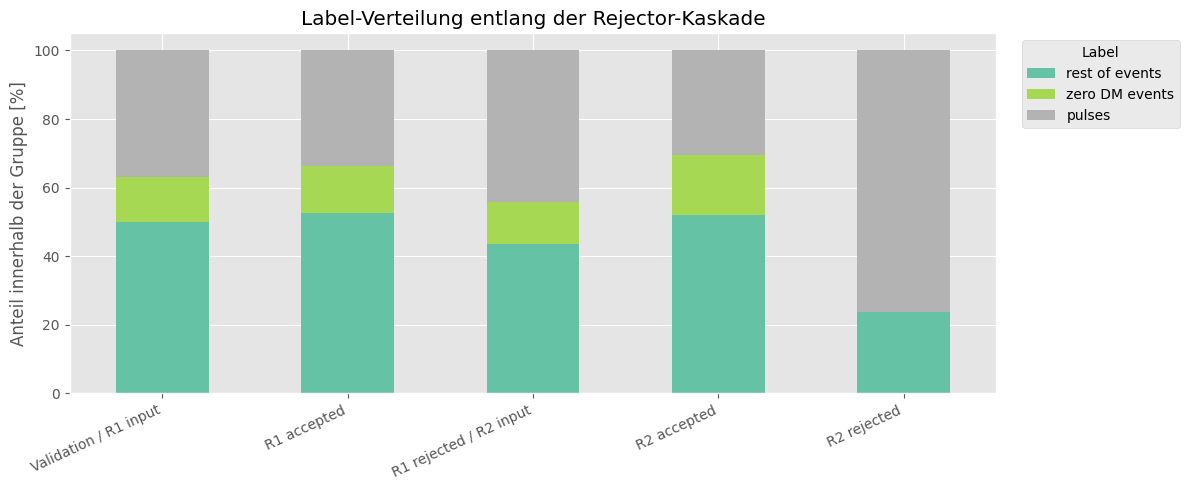

In [21]:
masks = {
    "Validation / R1 input": np.ones(len(results), dtype=bool),
    "R1 accepted": ~results.r1_rejected,
    "R1 rejected / R2 input": results.r1_rejected,
    "R2 accepted": results.r2_input & ~results.r2_rejected,
    "R2 rejected": results.r2_rejected,
}

parent_sizes = {
    "Validation / R1 input": len(results),
    "R1 accepted": len(results),
    "R1 rejected / R2 input": len(results),
    "R2 accepted": int(results.r2_input.sum()),
    "R2 rejected": int(results.r2_input.sum()),
}
routing_summary = pd.DataFrame([
    {"group": name, "count": int(mask.sum()),
     "percent_of_validation": 100 * mask.mean(),
     "percent_of_rejector_input": 100 * mask.sum() / parent_sizes[name] if parent_sizes[name] else np.nan}
    for name, mask in masks.items()
]).set_index("group")
display(routing_summary.style.format({"percent_of_validation": "{:.2f}%", "percent_of_rejector_input": "{:.2f}%"}))

label_counts = pd.concat(
    {name: results.loc[mask, "label"].value_counts().reindex(LABEL_MAP.values(), fill_value=0)
     for name, mask in masks.items()}, axis=1
).T
label_percent = label_counts.div(label_counts.sum(axis=1), axis=0).mul(100)
display(label_counts.style.set_caption("Label counts"))
display(label_percent.style.format("{:.2f}%").set_caption("Label distribution within each routing group"))

ax = label_percent.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="Set2")
ax.set(ylabel="Anteil innerhalb der Gruppe [%]", xlabel="", title="Label-Verteilung entlang der Rejector-Kaskade")
ax.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

,routing_decision,sample_count,percent_of_validation
f_small,R1 accepted,"120,422",70.00%
f_mid,"R1 rejected, R2 accepted","36,127",21.00%
f_large,"R1 rejected, R2 rejected","15,483",9.00%


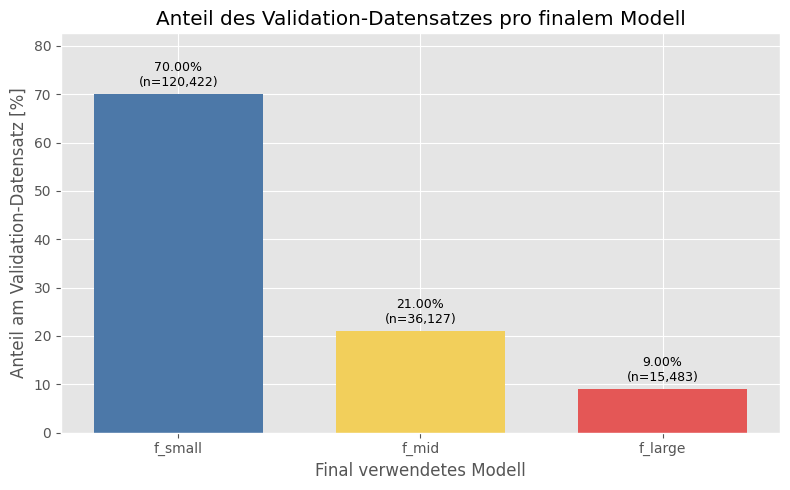

In [23]:
# Übersicht: Welcher Anteil des gesamten Validation-Datensatzes endet bei welchem Modell?
destination_order = ["f_small", "f_mid", "f_large"]
route_to_model = {
    "R1 accepted": "f_small",
    "R2 accepted": "f_mid",
    "R2 rejected": "f_large",
}
route_description = {
    "f_small": "R1 accepted",
    "f_mid": "R1 rejected, R2 accepted",
    "f_large": "R1 rejected, R2 rejected",
}

destination = results["final_route"].map(route_to_model)
destination_counts = destination.value_counts().reindex(destination_order, fill_value=0)
final_routing_overview = pd.DataFrame({
    "routing_decision": [route_description[model] for model in destination_order],
    "sample_count": destination_counts,
    "percent_of_validation": destination_counts.div(len(results)).mul(100),
}, index=destination_order)

assert final_routing_overview["sample_count"].sum() == len(results)
assert np.isclose(final_routing_overview["percent_of_validation"].sum(), 100.0)
display(
    final_routing_overview.style
    .format({"sample_count": "{:,}", "percent_of_validation": "{:.2f}%"})
    .set_caption("Finales Routing des gesamten Validation-Datensatzes")
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    destination_order, final_routing_overview["percent_of_validation"],
    color=["#4C78A8", "#F2CF5B", "#E45756"], width=0.7,
)
ax.bar_label(
    bars,
    labels=[f"{value:.2f}%\n(n={count:,})" for value, count in zip(
        final_routing_overview["percent_of_validation"], final_routing_overview["sample_count"]
    )],
    padding=4, fontsize=9,
)
ax.set(
    title="Anteil des Validation-Datensatzes pro finalem Modell",
    xlabel="Final verwendetes Modell", ylabel="Anteil am Validation-Datensatz [%]",
)
ax.set_ylim(0, max(final_routing_overview["percent_of_validation"].max() * 1.18, 10))
plt.tight_layout()
plt.show()

final_routing_overview.to_csv(OUTPUT_DIR / "validation_routing_overview.csv")

## SNR und DM: Mittelwert und Varianz

Die Varianz wird als Populationsvarianz (`ddof=0`) berechnet. Ausgegeben werden Eingang sowie beide Ausgänge jedes Rejectors.

In [24]:
def numeric_summary(frame, group_masks, columns=("snr", "dm")):
    rows = []
    for group, mask in group_masks.items():
        subset = frame.loc[mask]
        for column in columns:
            values = subset[column].dropna().to_numpy()
            rows.append({
                "group": group, "variable": column.upper(), "n": len(values),
                "mean": values.mean() if len(values) else np.nan,
                "variance_ddof0": values.var(ddof=0) if len(values) else np.nan,
                "std_ddof0": values.std(ddof=0) if len(values) else np.nan,
                "min": values.min() if len(values) else np.nan,
                "median": np.median(values) if len(values) else np.nan,
                "max": values.max() if len(values) else np.nan,
            })
    return pd.DataFrame(rows).set_index(["group", "variable"])

numeric_stats = numeric_summary(results, masks)
numeric_stats.to_csv(OUTPUT_DIR / "snr_dm_summary.csv")
display(numeric_stats.style.format(precision=4))

## SNR-Stufen und DM-Verteilungen

,3.400000,3.600000,4.000000,4.100000,4.200000,4.300000,4.400000,4.500000,4.600000,4.700000,4.800000,4.900000,5.000000,5.100000,5.200000,5.300000,5.400000,5.500000,5.600000,5.700000,5.800000,5.900000,6.100000,6.200000,6.300000,6.400000,6.500000,6.700000,6.800000,6.900000,7.000000,7.200000,7.300000,7.500000,7.600000,7.800000,7.900000,8.000000,8.200000,8.400000,8.500000,9.600000,9.700000,10.800000,11.300000,11.500000,11.800000,12.400000,12.500000,13.000000,13.600000,14.000000,14.700000,15.100000,16.100000,17.000000,18.100000,18.600000,21.299999,29.500000,31.900000,42.700001,45.400002,46.400002,56.500000,59.200001,70.199997
Validation / R1 input,256,256,256,256,8960,13056,12800,6656,4096,3072,4096,3328,1536,1536,2304,1792,1792,768,1024,768,768,256,256,768,1024,512,512,512,512,256,1024,512,512,768,512,512,256,256,512,256,256,256,256,512,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256,256
R1 accepted,4,0,110,248,5035,7976,7932,3546,2193,2060,2189,2255,589,1148,1170,1272,1072,482,805,705,680,235,242,725,939,477,483,359,491,240,790,473,483,728,486,492,244,238,488,247,245,250,252,499,235,182,249,256,255,255,256,253,253,241,250,256,254,256,256,221,239,245,222,256,234,253,212
R1 rejected / R2 input,252,256,146,8,3925,5080,4868,3110,1903,1012,1907,1073,947,388,1134,520,720,286,219,63,88,21,14,43,85,35,29,153,21,16,234,39,29,40,26,20,12,18,24,9,11,6,4,13,21,74,7,0,1,1,0,3,3,15,6,0,2,0,0,35,17,11,34,0,22,3,44
R2 accepted,252,256,146,0,2411,2599,2832,1939,1117,471,921,518,783,305,579,387,404,233,185,53,51,10,6,20,63,31,20,128,13,9,226,31,22,22,11,15,0,12,12,6,7,3,0,1,9,74,2,0,1,0,0,1,3,11,2,0,1,0,0,0,0,0,29,0,5,3,28
R2 rejected,0,0,0,8,1514,2481,2036,1171,786,541,986,555,164,83,555,133,316,53,34,10,37,11,8,23,22,4,9,25,8,7,8,8,7,18,15,5,12,6,12,3,4,3,4,12,12,0,5,0,0,1,0,2,0,4,4,0,1,0,0,35,17,11,5,0,17,0,16


,Noise,3.x,4.x,5.x,6.x,7.x,8.x,9+
Validation / R1 input,85760,512,56576,12544,4352,4096,1280,6912
R1 accepted,63256,4,33544,8158,3956,3696,1218,6590
R1 rejected / R2 input,22504,508,23032,4386,396,400,62,322
R2 accepted,18848,508,12954,2990,290,327,37,173
R2 rejected,3656,0,10078,1396,106,73,25,149


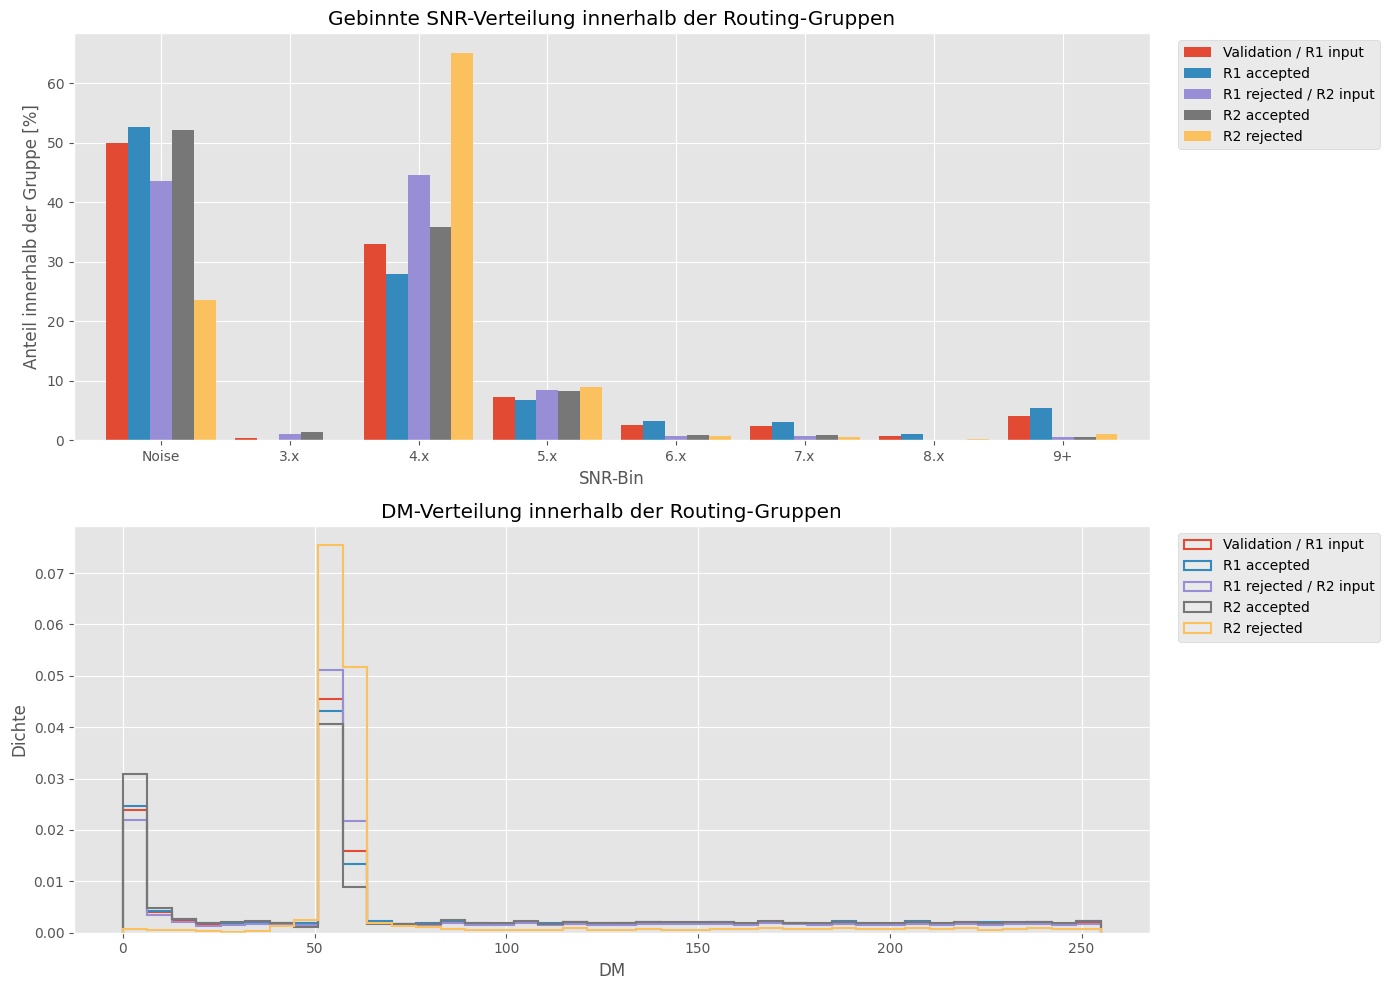

In [25]:
snr_level_counts = pd.concat(
    {name: results.loc[mask, "snr"].value_counts().sort_index() for name, mask in masks.items()},
    axis=1,
).fillna(0).astype(int)
snr_level_percent = snr_level_counts.div(snr_level_counts.sum(axis=0), axis=1).mul(100)
snr_level_counts.to_csv(OUTPUT_DIR / "snr_level_counts.csv")
snr_level_percent.to_csv(OUTPUT_DIR / "snr_level_percent_within_route.csv")
display(snr_level_counts.T.style.set_caption("Exact SNR-level counts per routing group"))

# Noise = Samples ohne SNR; danach 3.x, 4.x, ..., 8.x und 9+.
snr_numeric_bin_labels = [f"{value}.x" for value in range(3, 9)] + ["9+"]
snr_bin_labels = ["Noise"] + snr_numeric_bin_labels
snr_bins = list(range(3, 10)) + [np.inf]
results["snr_bin"] = pd.cut(
    results["snr"], bins=snr_bins, labels=snr_numeric_bin_labels, right=False, include_lowest=True
)
results["snr_bin"] = results["snr_bin"].cat.add_categories(["Noise"])
results.loc[results["snr"].isna(), "snr_bin"] = "Noise"
snr_bin_counts = pd.concat(
    {name: results.loc[mask, "snr_bin"].value_counts(sort=False).reindex(snr_bin_labels, fill_value=0)
     for name, mask in masks.items()}, axis=1
).astype(int)
snr_bin_percent = snr_bin_counts.div(snr_bin_counts.sum(axis=0), axis=1).mul(100)
snr_bin_counts.to_csv(OUTPUT_DIR / "snr_bin_counts.csv")
snr_bin_percent.to_csv(OUTPUT_DIR / "snr_bin_percent_within_route.csv")
display(snr_bin_counts.T.style.set_caption("SNR-bin counts per routing group"))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
snr_bin_percent.plot(kind="bar", ax=axes[0], width=0.85)
axes[0].set(title="Gebinnte SNR-Verteilung innerhalb der Routing-Gruppen", xlabel="SNR-Bin", ylabel="Anteil innerhalb der Gruppe [%]")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

for name, mask in masks.items():
    axes[1].hist(results.loc[mask, "dm"], bins=40, density=True, histtype="step", linewidth=1.5, label=name)
axes[1].set(title="DM-Verteilung innerhalb der Routing-Gruppen", xlabel="DM", ylabel="Dichte")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

,validation_count,percent_of_validation,f_small (R1 accepted),f_mid (R2 accepted),f_large (R2 rejected)
snr_bin,,,,,
Noise,85760,49.85%,73.76%,21.98%,4.26%
3.x,512,0.30%,0.78%,99.22%,0.00%
4.x,56576,32.89%,59.29%,22.90%,17.81%
5.x,12544,7.29%,65.04%,23.84%,11.13%
6.x,4352,2.53%,90.90%,6.66%,2.44%
7.x,4096,2.38%,90.23%,7.98%,1.78%
8.x,1280,0.74%,95.16%,2.89%,1.95%
9+,6912,4.02%,95.34%,2.50%,2.16%


Validation samples: 172,032; davon Noise ohne SNR: 85,760


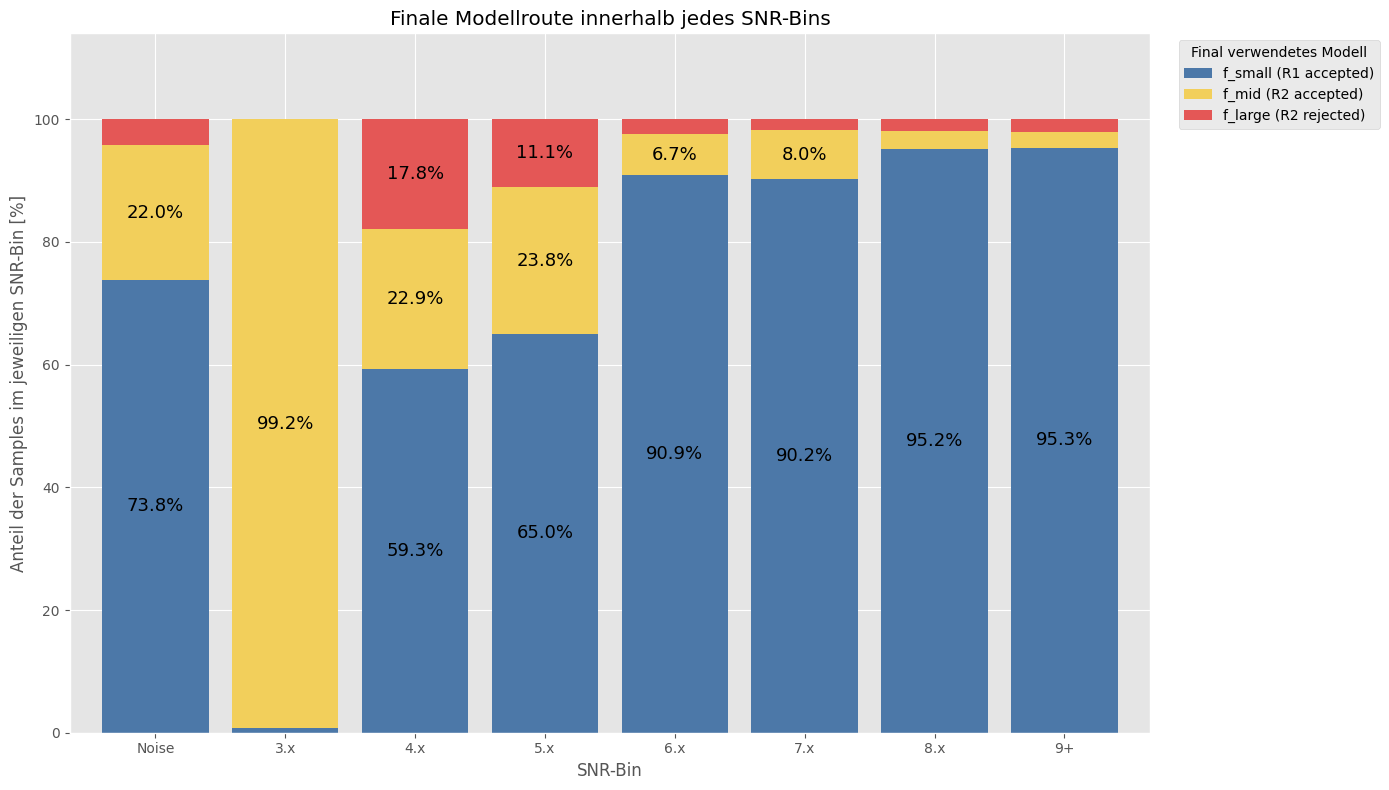

In [26]:
# Anteil der finalen Modellrouten innerhalb jedes SNR-Bins
route_order = ["R1 accepted", "R2 accepted", "R2 rejected"]
route_labels = {
    "R1 accepted": "f_small (R1 accepted)",
    "R2 accepted": "f_mid (R2 accepted)",
    "R2 rejected": "f_large (R2 rejected)",
}
snr_route_counts = pd.crosstab(
    results["snr_bin"], results["final_route"], dropna=True
).reindex(index=snr_bin_labels, columns=route_order, fill_value=0)
snr_route_counts.columns = [route_labels[column] for column in snr_route_counts.columns]

samples_per_snr_bin = snr_route_counts.sum(axis=1)
snr_route_percent = snr_route_counts.div(samples_per_snr_bin.replace(0, np.nan), axis=0).mul(100)
snr_validation_summary = pd.concat([
    samples_per_snr_bin.rename("validation_count"),
    samples_per_snr_bin.div(samples_per_snr_bin.sum()).mul(100).rename("percent_of_validation"),
    snr_route_percent,
], axis=1)
display(
    snr_validation_summary.style
    .format({column: "{:.2f}%" for column in snr_validation_summary.columns if column != "validation_count"})
    .set_caption("Validation-SNR-Verteilung und bedingte Modellroute je SNR-Bin")
)

n_without_snr = int(results["snr"].isna().sum())
print(f"Validation samples: {samples_per_snr_bin.sum():,}; davon Noise ohne SNR: {n_without_snr:,}")

ax = snr_route_percent.plot(
    kind="bar", stacked=True, figsize=(14, 8), width=0.82,
    color=["#4C78A8", "#F2CF5B", "#E45756"],
)
# Große Anteile innen beschriften; kleine Anteile als Callout oberhalb des Balkens.
for x_pos, (_, row) in enumerate(snr_route_percent.iterrows()):
    bottom = 0.0
    small_label_index = 0
    for route_index, value in enumerate(row):
        if pd.isna(value) or value <= 0:
            continue
        segment_center = bottom + value / 2
        if value >= 6:
            ax.text(x_pos, segment_center, f"{value:.1f}%", ha="center", va="center", fontsize=13)
        # else:
        #     x_offset = (-0.22, 0.0, 0.22)[route_index]
        #     ax.annotate(
        #         f"{value:.1f}%", xy=(x_pos, segment_center),
        #         xytext=(x_pos + x_offset, 104 + 3 * small_label_index),
        #         ha="center", va="bottom", fontsize=13,
        #         arrowprops=dict(arrowstyle="-", color="0.35", lw=0.7),
        #     )
        #     small_label_index += 1
        bottom += value
ax.set(
    title="Finale Modellroute innerhalb jedes SNR-Bins",
    xlabel="SNR-Bin", ylabel="Anteil der Samples im jeweiligen SNR-Bin [%]",
)
ax.set_ylim(0, 114)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Final verwendetes Modell", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

snr_route_counts.to_csv(OUTPUT_DIR / "snr_route_counts_by_bin.csv")
snr_route_percent.to_csv(OUTPUT_DIR / "snr_route_percent_by_bin.csv")
snr_validation_summary.to_csv(OUTPUT_DIR / "snr_validation_and_routes_by_bin.csv")

,input_count,rejected_count,mean_reject_score,accepted_count,accepted_percent
snr_bin,,,,,
Noise,85760,22504,0.4559,63256,73.76%
3.x,512,508,0.6112,4,0.78%
4.x,56576,23032,0.5158,33544,59.29%
5.x,12544,4386,0.4363,8158,65.04%
6.x,4352,396,0.1781,3956,90.90%
7.x,4096,400,0.1751,3696,90.23%
8.x,1280,62,0.1192,1218,95.16%
9+,6912,322,0.0947,6590,95.34%


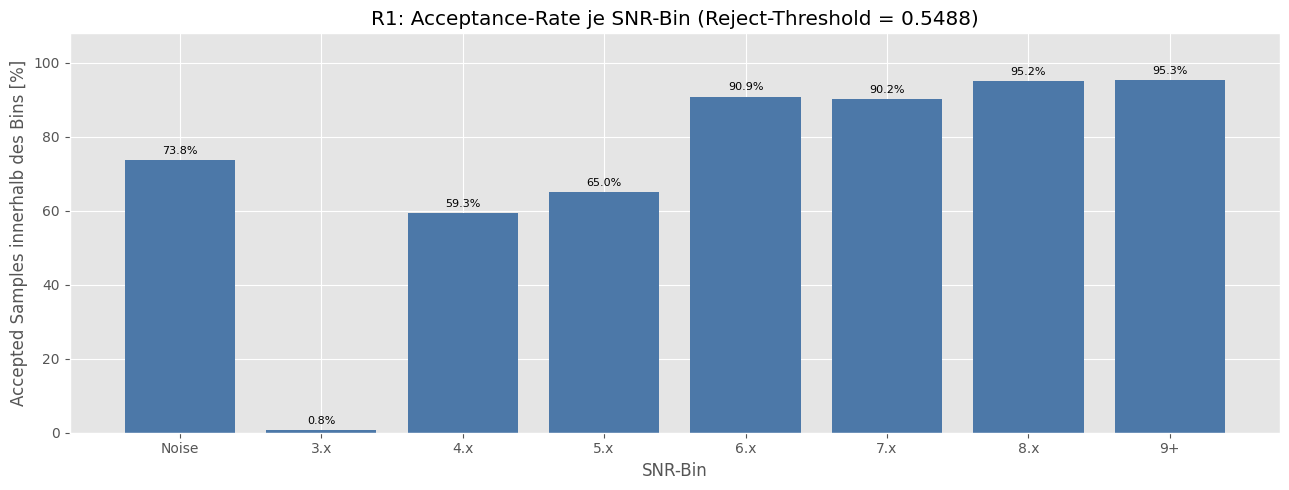

,input_count,rejected_count,mean_reject_score,accepted_count,accepted_percent
snr_bin,,,,,
Noise,22504,3656,0.1437,18848,83.75%
3.x,508,0,0.0159,508,100.00%
4.x,23032,10078,0.3709,12954,56.24%
5.x,4386,1396,0.2922,2990,68.17%
6.x,396,106,0.2762,290,73.23%
7.x,400,73,0.1611,327,81.75%
8.x,62,25,0.3815,37,59.68%
9+,322,149,0.3690,173,53.73%


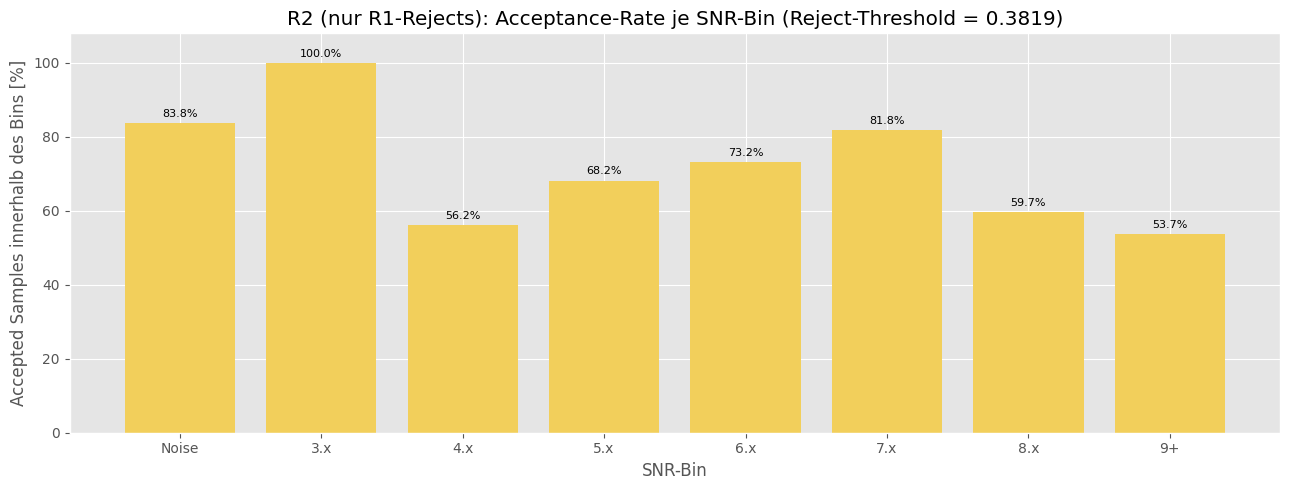

In [27]:
# Akzeptanzrate und mittlerer Reject-Score je SNR-Bin, separat für R1 und R2
def acceptance_by_snr_bin(frame, input_mask, rejected_column, score_column):
    subset = frame.loc[input_mask].copy()
    grouped = subset.groupby("snr_bin", observed=False)
    summary = grouped.agg(
        input_count=(rejected_column, "size"),
        rejected_count=(rejected_column, "sum"),
        mean_reject_score=(score_column, "mean"),
    ).reindex(snr_bin_labels)
    summary["accepted_count"] = summary["input_count"] - summary["rejected_count"]
    summary["accepted_percent"] = (
        summary["accepted_count"].div(summary["input_count"].replace(0, np.nan)).mul(100)
    )
    return summary


def plot_acceptance(summary, rejector_name, threshold, color):
    values = summary["accepted_percent"].to_numpy(dtype=float)
    x = np.arange(len(summary))
    fig, ax = plt.subplots(figsize=(13, 5))
    bars = ax.bar(x, np.nan_to_num(values, nan=0.0), color=color, width=0.78)
    labels = [f"{value:.1f}%" if np.isfinite(value) else "n=0" for value in values]
    ax.bar_label(bars, labels=labels, padding=3, fontsize=8)
    ax.set_xticks(x, summary.index)
    ax.set_ylim(0, 108)
    ax.set(
        title=f"{rejector_name}: Acceptance-Rate je SNR-Bin (Reject-Threshold = {threshold:.4f})",
        xlabel="SNR-Bin", ylabel="Accepted Samples innerhalb des Bins [%]",
    )
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()


r1_snr_acceptance = acceptance_by_snr_bin(
    results, np.ones(len(results), dtype=bool), "r1_rejected", "r1_score"
)
display(
    r1_snr_acceptance.style
    .format({"mean_reject_score": "{:.4f}", "accepted_percent": "{:.2f}%"})
    .set_caption("R1: Eingang, Reject-Score und Acceptance-Rate je SNR-Bin")
)
plot_acceptance(r1_snr_acceptance, "R1", R1_THRESHOLD, "#4C78A8")

# R2 wird nur auf seinem tatsächlichen Eingang ausgewertet: den R1-Rejects.
r2_snr_acceptance = acceptance_by_snr_bin(
    results, results["r2_input"], "r2_rejected", "r2_score"
)
display(
    r2_snr_acceptance.style
    .format({"mean_reject_score": "{:.4f}", "accepted_percent": "{:.2f}%"})
    .set_caption("R2: Eingang, Reject-Score und Acceptance-Rate je SNR-Bin (nur R1-Rejects)")
)
plot_acceptance(r2_snr_acceptance, "R2 (nur R1-Rejects)", R2_THRESHOLD, "#F2CF5B")

r1_snr_acceptance.to_csv(OUTPUT_DIR / "r1_acceptance_by_snr_bin.csv")
r2_snr_acceptance.to_csv(OUTPUT_DIR / "r2_acceptance_by_snr_bin.csv")

,routing_group,n_routed_samples,n_correct,n_incorrect,validation_accuracy,full_validation_accuracy
model,,,,,,
f_small,R1 accepted,120422,97760,22662,81.1812%,74.2100%
f_mid,R2 accepted,36127,35873,254,99.2969%,94.8000%
f_large,R2 rejected,15483,15277,206,98.6695%,99.3400%


Gesamte kaskadierte Validation-Accuracy: 86.5595%


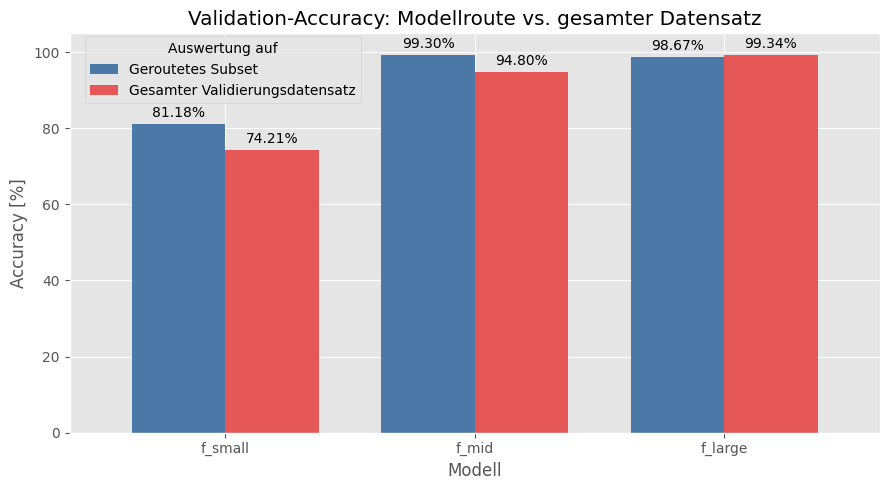

In [28]:
# Validation-Accuracy jedes Klassifikators ausschließlich auf seiner finalen Route
model_routes = [
    ("f_small", "R1 accepted", "f_small_prediction"),
    ("f_mid", "R2 accepted", "f_mid_prediction"),
    ("f_large", "R2 rejected", "f_large_prediction"),
]

accuracy_rows = []
for model_name, route_name, prediction_column in model_routes:
    route_mask = results["final_route"].eq(route_name)
    correct = results.loc[route_mask, prediction_column].eq(
        results.loc[route_mask, "label_binary"]
    )
    accuracy_rows.append({
        "model": model_name,
        "routing_group": route_name,
        "n_routed_samples": int(route_mask.sum()),
        "n_correct": int(correct.sum()),
        "n_incorrect": int((~correct).sum()),
        "validation_accuracy": correct.mean() if len(correct) else np.nan,
    })

routed_accuracy = pd.DataFrame(accuracy_rows).set_index("model")
routed_accuracy["full_validation_accuracy"] = pd.Series({
    "f_small": 0.7421,
    "f_mid": 0.9480,
    "f_large": 0.9934,
})
pipeline_accuracy = results["prediction_correct"].mean()
display(
    routed_accuracy.style
    .format({
        "validation_accuracy": "{:.4%}",
        "full_validation_accuracy": "{:.4%}",
    })
    .set_caption("Validation-Accuracy auf der Modellroute und dem gesamten Datensatz")
)
print(f"Gesamte kaskadierte Validation-Accuracy: {pipeline_accuracy:.4%}")

accuracy_plot_data = routed_accuracy[[
    "validation_accuracy", "full_validation_accuracy"
]].mul(100).rename(columns={
    "validation_accuracy": "Geroutetes Subset",
    "full_validation_accuracy": "Gesamter Validierungsdatensatz",
})
ax = accuracy_plot_data.plot(
    kind="bar", figsize=(9, 5), color=["#4C78A8", "#E45756"], width=0.75,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)
ax.set(
    title="Validation-Accuracy: Modellroute vs. gesamter Datensatz",
    xlabel="Modell", ylabel="Accuracy [%]",
)
ax.set_ylim(0, 105)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Auswertung auf", loc="upper left", bbox_to_anchor=(0.01, 1.01))
plt.tight_layout()
plt.show()

routed_accuracy.to_csv(OUTPUT_DIR / "routed_model_validation_accuracy.csv")
pd.DataFrame([{"pipeline_validation_accuracy": pipeline_accuracy}]).to_csv(
    OUTPUT_DIR / "cascaded_pipeline_validation_accuracy.csv", index=False
)

## Score-Verteilungen und kompakter Export

,R1 (all validation),R2 (R1 rejects only)
count,1.720320e+05,5.161000e+04
mean,4.439132e-01,2.593062e-01
std,2.173164e-01,3.003136e-01
min,5.436697e-24,3.078665e-12
25%,3.125462e-01,3.446124e-04
50%,4.384852e-01,1.346573e-01
75%,5.824316e-01,4.722616e-01
max,9.999999e-01,9.800780e-01


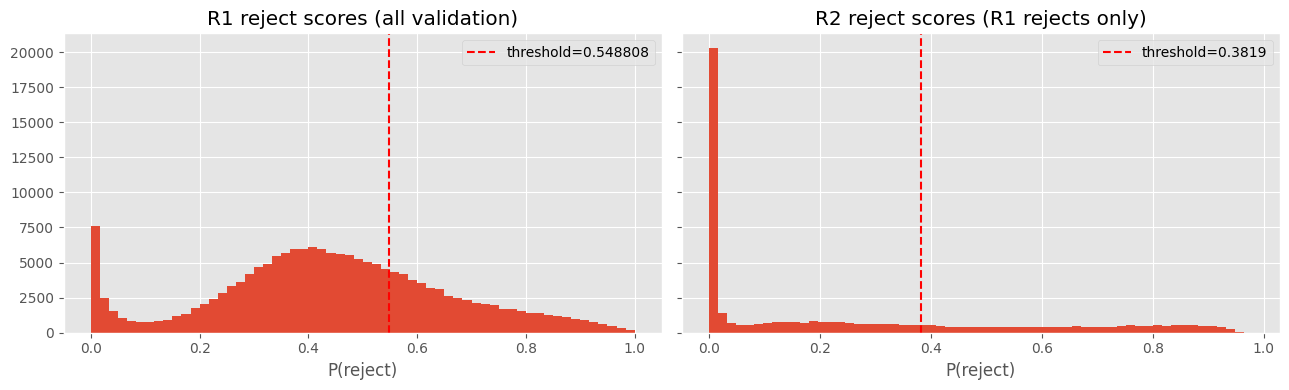

All tables written to /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/rejector_analysis


In [29]:
score_summary = pd.DataFrame({
    "R1 (all validation)": results.r1_score.describe(),
    "R2 (R1 rejects only)": results.loc[results.r2_input, "r2_score"].describe(),
})
display(score_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
axes[0].hist(results.r1_score, bins=60)
axes[0].axvline(R1_THRESHOLD, color="red", linestyle="--", label=f"threshold={R1_THRESHOLD:.6f}")
axes[0].set(title="R1 reject scores (all validation)", xlabel="P(reject)")
axes[0].legend()
axes[1].hist(results.loc[results.r2_input, "r2_score"], bins=60)
axes[1].axvline(R2_THRESHOLD, color="red", linestyle="--", label=f"threshold={R2_THRESHOLD:.4f}")
axes[1].set(title="R2 reject scores (R1 rejects only)", xlabel="P(reject)")
axes[1].legend()
plt.tight_layout()
plt.show()

label_counts.to_csv(OUTPUT_DIR / "label_counts_by_route.csv")
label_percent.to_csv(OUTPUT_DIR / "label_percent_by_route.csv")
routing_summary.to_csv(OUTPUT_DIR / "routing_summary.csv")
score_summary.to_csv(OUTPUT_DIR / "score_summary.csv")
print(f"All tables written to {OUTPUT_DIR}")

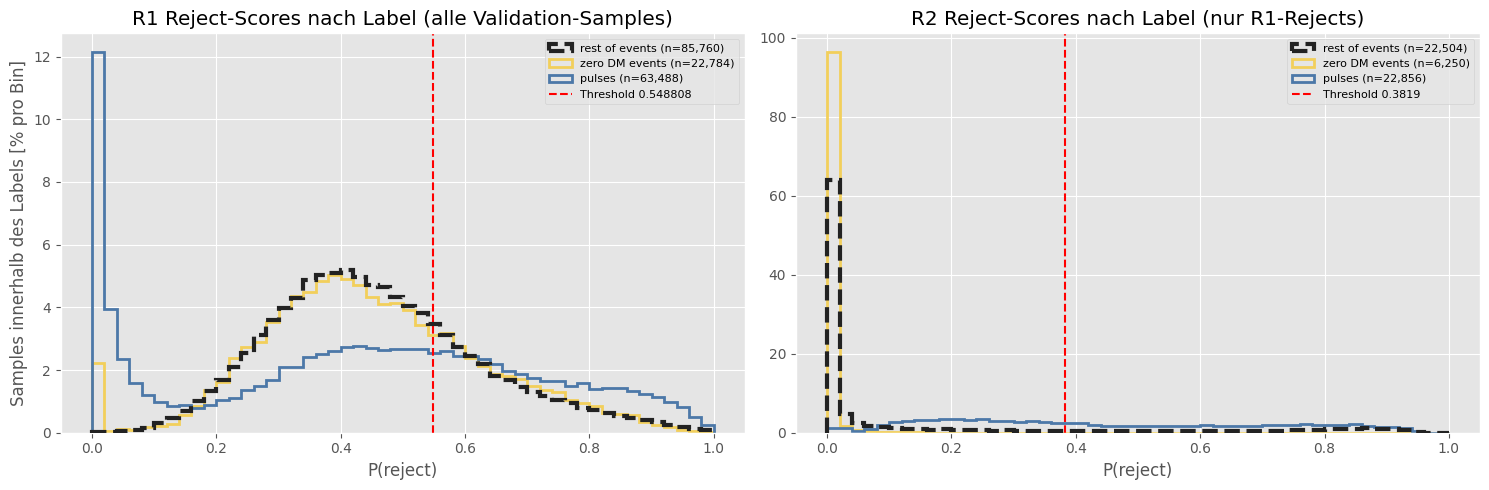

,rejector,label,n_input,mean_reject_score,median_reject_score,accepted_percent,rejected_percent
0,R1,rest of events,85760,0.4559,0.4376,73.76%,26.24%
1,R1,zero DM events,22784,0.4493,0.4334,72.57%,27.43%
2,R1,pulses,63488,0.4258,0.4435,64.00%,36.00%
3,R2,rest of events,22504,0.1437,0.0028,83.75%,16.25%
4,R2,zero DM events,6250,0.0032,0.0000,99.97%,0.03%
5,R2,pulses,22856,0.4432,0.3965,48.26%,51.74%


In [30]:
# Normalisierte Reject-Score-Verteilungen getrennt nach Metadaten-Label
label_order = list(LABEL_MAP.values())
label_colors = {
    "rest of events": "#222222",
    "zero DM events": "#F2CF5B",
    "pulses": "#4C78A8",
}
score_bins = np.linspace(0.0, 1.0, 51)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=False)

for label_name in label_order:
    values = results.loc[results["label"].eq(label_name), "r1_score"].dropna().to_numpy()
    weights = np.full(len(values), 100 / len(values)) if len(values) else None
    axes[0].hist(
        values, bins=score_bins, weights=weights,
        histtype="step",
        linewidth=3 if label_name == "rest of events" else 2,
        linestyle="--" if label_name == "rest of events" else "-",
        color=label_colors[label_name],
        zorder=4 if label_name == "rest of events" else 2,
        label=f"{label_name} (n={len(values):,})",
    )
axes[0].axvline(R1_THRESHOLD, color="red", linestyle="--", linewidth=1.5, label=f"Threshold {R1_THRESHOLD:.6f}")
axes[0].set(
    title="R1 Reject-Scores nach Label (alle Validation-Samples)",
    xlabel="P(reject)", ylabel="Samples innerhalb des Labels [% pro Bin]",
)
axes[0].legend(fontsize=8)

r2_input_results = results.loc[results["r2_input"]]
for label_name in label_order:
    values = r2_input_results.loc[r2_input_results["label"].eq(label_name), "r2_score"].dropna().to_numpy()
    weights = np.full(len(values), 100 / len(values)) if len(values) else None
    axes[1].hist(
        values, bins=score_bins, weights=weights,
        histtype="step",
        linewidth=3 if label_name == "rest of events" else 2,
        linestyle="--" if label_name == "rest of events" else "-",
        color=label_colors[label_name],
        zorder=4 if label_name == "rest of events" else 2,
        label=f"{label_name} (n={len(values):,})",
    )
axes[1].axvline(R2_THRESHOLD, color="red", linestyle="--", linewidth=1.5, label=f"Threshold {R2_THRESHOLD:.4f}")
axes[1].set(
    title="R2 Reject-Scores nach Label (nur R1-Rejects)",
    xlabel="P(reject)",
)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

def score_routing_summary(frame, score_column, rejected_column, rejector_name):
    rows = []
    for label_name in label_order:
        group = frame.loc[frame["label"].eq(label_name)]
        rows.append({
            "rejector": rejector_name, "label": label_name, "n_input": len(group),
            "mean_reject_score": group[score_column].mean(),
            "median_reject_score": group[score_column].median(),
            "accepted_percent": 100 * (~group[rejected_column]).mean() if len(group) else np.nan,
            "rejected_percent": 100 * group[rejected_column].mean() if len(group) else np.nan,
        })
    return pd.DataFrame(rows)

score_by_label_summary = pd.concat([
    score_routing_summary(results, "r1_score", "r1_rejected", "R1"),
    score_routing_summary(r2_input_results, "r2_score", "r2_rejected", "R2"),
], ignore_index=True)
display(
    score_by_label_summary.style.format({
        "mean_reject_score": "{:.4f}", "median_reject_score": "{:.4f}",
        "accepted_percent": "{:.2f}%", "rejected_percent": "{:.2f}%",
    }).set_caption("Reject-Scores und Routingraten je Metadaten-Label")
)
score_by_label_summary.to_csv(OUTPUT_DIR / "rejector_scores_and_routing_by_label.csv", index=False)